<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1] "First rows of the dataset:"
   Country Pre_Improved_Sanitation Post_Improved_Sanitation Sample_Size
1    Kenya                      56                       70         100
2   Uganda                      53                       69         100
3 Tanzania                      61                       69         100
4   Rwanda                      63                       75         100
5 Ethiopia                      47                       65         100
6    Nepal                      53                       67         100
[1] "Dataset summary:"
      Country   Pre_Improved_Sanitation Post_Improved_Sanitation  Sample_Size 
 Length   :10   Min.   :47.00           Min.   :65.00            Min.   :100  
 N.unique :10   1st Qu.:52.25           1st Qu.:68.25            1st Qu.:100  
 N.blank  : 0   Median :53.50           Median :69.50            Median :100  
 Min.nchar: 5   Mean   :54.40           Mean   :69.90            Mean   :100  
 Max.nchar:10   3rd Qu.:56.00           3rd Q

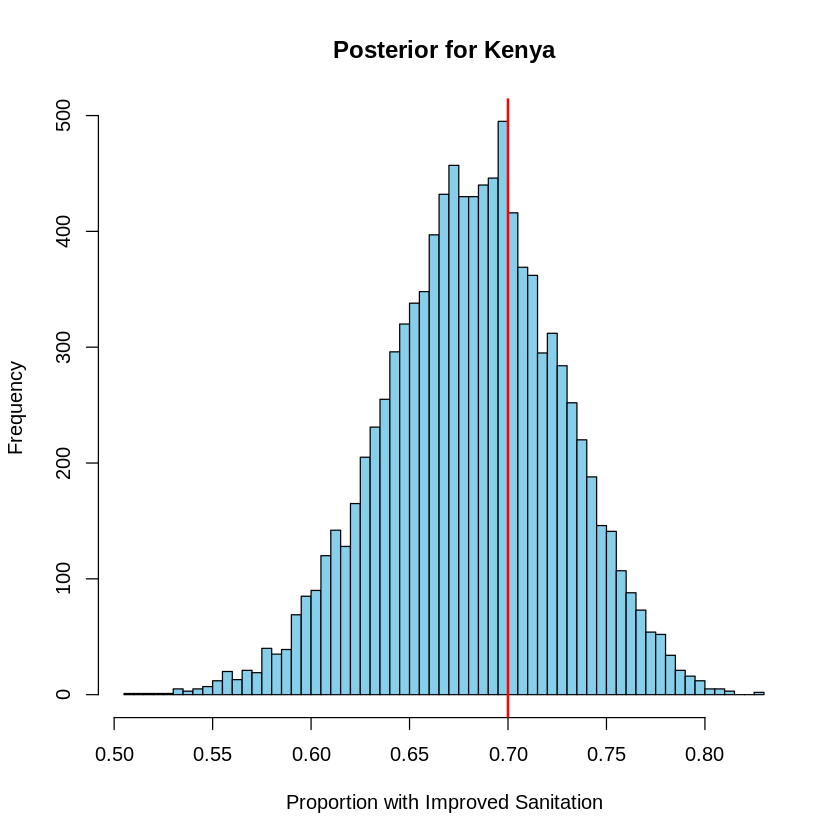

[1] "Summary Table:"
      Country Pre_Improved_Sanitation Post_Improved_Sanitation
1       Kenya                      56                       70
2      Uganda                      53                       69
3    Tanzania                      61                       69
4      Rwanda                      63                       75
5    Ethiopia                      47                       65
6       Nepal                      53                       67
7  Bangladesh                      54                       71
8    Cambodia                      49                       75
9       Haiti                      56                       70
10  Guatemala                      52                       68
   Prob_Pre_Above_70 Prob_Post_Above_70
1             0.0004             0.3457
2             0.0001             0.2750
3             0.0137             0.2775
4             0.0337             0.7426
5             0.0000             0.0771
6             0.0001             0.1568
7     

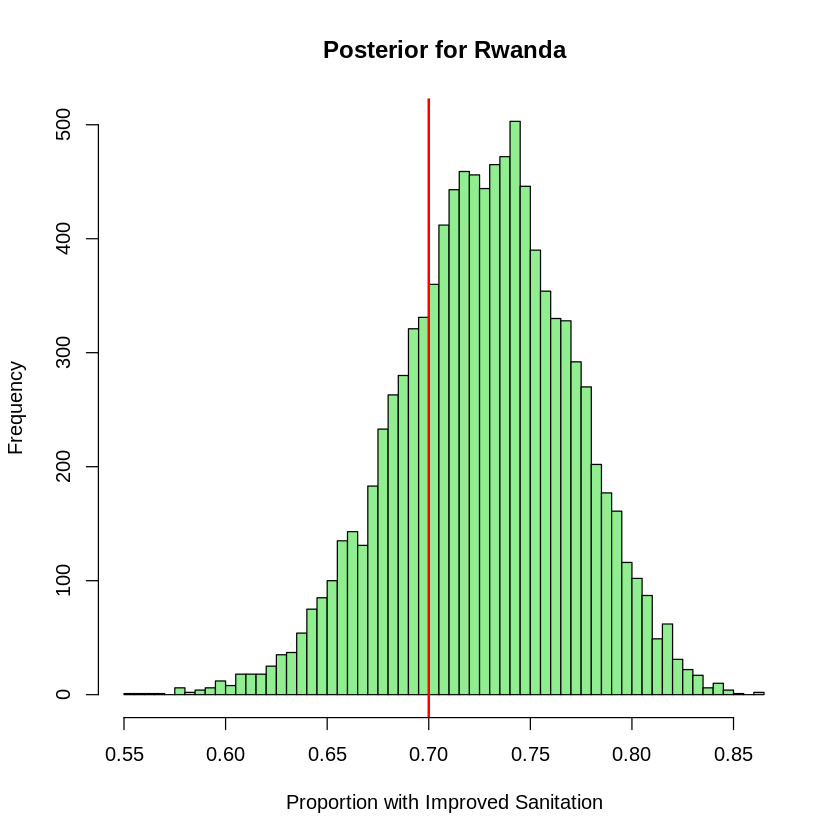


Reflection:

The Bayesian analysis indicates that improved sanitation access
increased across all countries in the dataset after the intervention.

The average observed pre-intervention sanitation count across the
countries is approximately 54 out of 100 people, while the average
post-intervention count is approximately 70 out of 100.

The posterior distributions combine the prior belief with the observed
survey data.

Monte Carlo simulation allows us to estimate the probability that
sanitation access is greater than 70% for each country.

Countries with higher post-intervention sanitation counts have a
greater posterior probability of exceeding the 70% target.

The posterior means also allow us to compare expected improvements
between countries.

Cambodia shows the largest expected improvement in this dataset. Its
posterior mean increases by approximately 23.6 percentage points.

Changing the prior changes the posterior estimates slightly. A stronger
Beta(10,10) prior pulls estimates

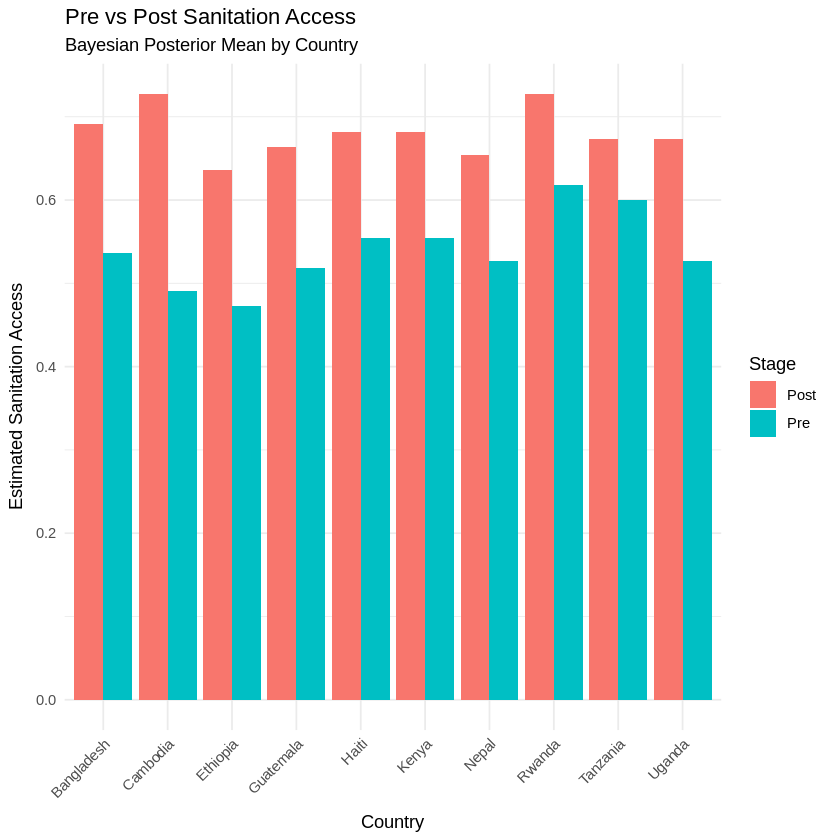

In [1]:
# CST184 Week 11
# Bayesian Analysis & Monte Carlo Simulations
# Evaluating Sanitation Access with Bayesian Methods

# Step 1: Load and explore the data

data <- read.csv("sdg6_sanitation_pre_post.csv")

print("First rows of the dataset:")
print(head(data))

print("Dataset summary:")
print(summary(data))


# Step 2: Define prior beliefs

alpha_prior <- 5
beta_prior <- 5

print("Prior distribution:")
print(paste("Beta(", alpha_prior, ",", beta_prior, ")", sep = ""))


# Step 3: Calculate posterior for post-intervention data

data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation

data$Post_Beta <- beta_prior +
  (data$Sample_Size - data$Post_Improved_Sanitation)

print("Post-intervention posterior parameters:")

print(
  data[
    c(
      "Country",
      "Post_Improved_Sanitation",
      "Post_Alpha",
      "Post_Beta"
    )
  ]
)


# Try This: Calculate posterior for pre-intervention data

data$Pre_Alpha <- alpha_prior + data$Pre_Improved_Sanitation

data$Pre_Beta <- beta_prior +
  (data$Sample_Size - data$Pre_Improved_Sanitation)

print("Pre-intervention posterior parameters:")

print(
  data[
    c(
      "Country",
      "Pre_Improved_Sanitation",
      "Pre_Alpha",
      "Pre_Beta"
    )
  ]
)


# Step 4: Monte Carlo simulation
# Probability post-intervention sanitation access is above 70%

set.seed(42)

data$Prob_Post_Above_70 <- sapply(
  1:nrow(data),
  function(i) {

    samples <- rbeta(
      10000,
      data$Post_Alpha[i],
      data$Post_Beta[i]
    )

    mean(samples > 0.7)
  }
)

print("Probability post-intervention access is above 70%:")

print(
  data[
    c(
      "Country",
      "Post_Improved_Sanitation",
      "Prob_Post_Above_70"
    )
  ]
)


# Try This: Calculate the same probability for pre-intervention data

set.seed(42)

data$Prob_Pre_Above_70 <- sapply(
  1:nrow(data),
  function(i) {

    samples <- rbeta(
      10000,
      data$Pre_Alpha[i],
      data$Pre_Beta[i]
    )

    mean(samples > 0.7)
  }
)

print("Probability pre-intervention access was above 70%:")

print(
  data[
    c(
      "Country",
      "Pre_Improved_Sanitation",
      "Prob_Pre_Above_70"
    )
  ]
)


# Compare pre and post probabilities

data$Probability_Change <- (
  data$Prob_Post_Above_70 -
  data$Prob_Pre_Above_70
)

print("Change in probability of sanitation access above 70%:")

print(
  data[
    c(
      "Country",
      "Prob_Pre_Above_70",
      "Prob_Post_Above_70",
      "Probability_Change"
    )
  ]
)


# Step 5: Visualise the posterior for the first country

set.seed(42)

samples <- rbeta(
  10000,
  data$Post_Alpha[1],
  data$Post_Beta[1]
)

hist(
  samples,
  breaks = 50,
  col = "skyblue",
  main = paste(
    "Posterior for",
    data$Country[1]
  ),
  xlab = "Proportion with Improved Sanitation"
)

abline(
  v = 0.7,
  col = "red",
  lwd = 2
)


# Try another country
# Rwanda is row 4 in this dataset

set.seed(42)

samples_rwanda <- rbeta(
  10000,
  data$Post_Alpha[4],
  data$Post_Beta[4]
)

hist(
  samples_rwanda,
  breaks = 50,
  col = "lightgreen",
  main = paste(
    "Posterior for",
    data$Country[4]
  ),
  xlab = "Proportion with Improved Sanitation"
)

abline(
  v = 0.7,
  col = "red",
  lwd = 2
)


# Step 6: Create a summary table

summary_table <- data[
  c(
    "Country",
    "Pre_Improved_Sanitation",
    "Post_Improved_Sanitation",
    "Prob_Pre_Above_70",
    "Prob_Post_Above_70"
  )
]

print("Summary Table:")
print(summary_table)


# Step 7: Calculate posterior means

data$Pre_Posterior_Mean <- (
  data$Pre_Alpha /
  (data$Pre_Alpha + data$Pre_Beta)
)

data$Post_Posterior_Mean <- (
  data$Post_Alpha /
  (data$Post_Alpha + data$Post_Beta)
)

data$Expected_Improvement <- (
  data$Post_Posterior_Mean -
  data$Pre_Posterior_Mean
)

print("Posterior means and expected improvement:")

print(
  data[
    c(
      "Country",
      "Pre_Posterior_Mean",
      "Post_Posterior_Mean",
      "Expected_Improvement"
    )
  ]
)


# Show expected improvement as percentages

data$Expected_Improvement_Percent <- (
  data$Expected_Improvement * 100
)

print("Expected improvement in percentage points:")

print(
  data[
    c(
      "Country",
      "Expected_Improvement_Percent"
    )
  ]
)


# Find the country with the greatest expected improvement

best_country <- data[
  which.max(data$Expected_Improvement),
]

print("Country with greatest expected improvement:")
print(best_country$Country)

print("Expected improvement:")
print(
  round(
    best_country$Expected_Improvement_Percent,
    2
  )
)


# Modification 1: Use Beta(1,1) prior

alpha_prior_1 <- 1
beta_prior_1 <- 1

data$Post_Alpha_Beta1 <- (
  alpha_prior_1 +
  data$Post_Improved_Sanitation
)

data$Post_Beta_Beta1 <- (
  beta_prior_1 +
  (
    data$Sample_Size -
    data$Post_Improved_Sanitation
  )
)

data$Post_Mean_Beta1 <- (
  data$Post_Alpha_Beta1 /
  (
    data$Post_Alpha_Beta1 +
    data$Post_Beta_Beta1
  )
)

print("Posterior means using Beta(1,1):")

print(
  data[
    c(
      "Country",
      "Post_Mean_Beta1"
    )
  ]
)


# Modification 2: Use Beta(10,10) prior

alpha_prior_10 <- 10
beta_prior_10 <- 10

data$Post_Alpha_Beta10 <- (
  alpha_prior_10 +
  data$Post_Improved_Sanitation
)

data$Post_Beta_Beta10 <- (
  beta_prior_10 +
  (
    data$Sample_Size -
    data$Post_Improved_Sanitation
  )
)

data$Post_Mean_Beta10 <- (
  data$Post_Alpha_Beta10 /
  (
    data$Post_Alpha_Beta10 +
    data$Post_Beta_Beta10
  )
)

print("Posterior means using Beta(10,10):")

print(
  data[
    c(
      "Country",
      "Post_Mean_Beta10"
    )
  ]
)


# Compare different priors

prior_comparison <- data.frame(
  Country = data$Country,
  Beta_1_1 = round(
    data$Post_Mean_Beta1,
    3
  ),
  Beta_5_5 = round(
    data$Post_Posterior_Mean,
    3
  ),
  Beta_10_10 = round(
    data$Post_Mean_Beta10,
    3
  )
)

print("Comparison of different priors:")
print(prior_comparison)


cat("
Prior Comparison:

Beta(1,1) is a weaker and more uniform prior. It allows the observed
data to have a stronger influence on the posterior result.

Beta(5,5) represents a moderate prior belief centred around 50%.

Beta(10,10) is stronger and pulls the posterior estimates slightly
more toward 50%.

Because each country has a sample size of 100, the observed data still
has a strong influence on all three posterior estimates.
")


# Create a pre vs post posterior mean plot

if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}

library(ggplot2)

plot_data <- data.frame(
  Country = rep(data$Country, 2),
  Stage = rep(
    c("Pre", "Post"),
    each = nrow(data)
  ),
  Posterior_Mean = c(
    data$Pre_Posterior_Mean,
    data$Post_Posterior_Mean
  )
)

ggplot(
  plot_data,
  aes(
    x = Country,
    y = Posterior_Mean,
    fill = Stage
  )
) +
  geom_col(
    position = "dodge"
  ) +
  labs(
    title = "Pre vs Post Sanitation Access",
    subtitle = "Bayesian Posterior Mean by Country",
    x = "Country",
    y = "Estimated Sanitation Access"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )


# Reflection

cat("
Reflection:

The Bayesian analysis indicates that improved sanitation access
increased across all countries in the dataset after the intervention.

The average observed pre-intervention sanitation count across the
countries is approximately 54 out of 100 people, while the average
post-intervention count is approximately 70 out of 100.

The posterior distributions combine the prior belief with the observed
survey data.

Monte Carlo simulation allows us to estimate the probability that
sanitation access is greater than 70% for each country.

Countries with higher post-intervention sanitation counts have a
greater posterior probability of exceeding the 70% target.

The posterior means also allow us to compare expected improvements
between countries.

Cambodia shows the largest expected improvement in this dataset. Its
posterior mean increases by approximately 23.6 percentage points.

Changing the prior changes the posterior estimates slightly. A stronger
Beta(10,10) prior pulls estimates more toward 50%, while Beta(1,1)
allows the observed survey results to have greater influence.

However, because there are 100 observations per country, the data has
a relatively strong influence compared with the prior.

This analysis demonstrates why Bayesian methods are useful for policy
evaluation. Instead of producing only a single estimate, Bayesian
analysis provides a probability distribution that represents
uncertainty.

This can help organisations evaluate whether an intervention is likely
to have achieved a target while still acknowledging uncertainty in
the available evidence.
")


# Summary

cat("
Summary:

This tutorial applied Bayesian updating using Beta prior distributions
and Binomial sanitation data.

Posterior distributions were calculated for both pre-intervention and
post-intervention sanitation access.

Monte Carlo simulations were used to estimate the probability that
sanitation access exceeded 70%.

Posterior means were used to estimate the expected improvement for each
country.

Different prior distributions were compared to show how prior beliefs
influence Bayesian results.

The analysis supports decision-making related to SDG 6: Clean Water
and Sanitation.
")